<a href="https://colab.research.google.com/github/aisha13dikko-sudo/using-synthetic-data-for-thermal-comfort-classification/blob/main/wk7_cold_failure_diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install datasets scikit-learn pandas numpy matplotlib --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from datasets import load_dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, confusion_matrix

In [4]:
dataset = load_dataset("kopetri/AutoTherm", "indoor")
df = dataset["train"].to_pandas()

def extract_participant_id(filename):
    match = re.search(r"participant_\d+", filename)
    return match.group() if match else "unknown"

df["participant_id"] = df["file_name"].apply(extract_participant_id)

test_participants = ["participant_16", "participant_14", "participant_20"]
train_participants = [p for p in df["participant_id"].unique() if p not in test_participants]

train_split = df[df["participant_id"].isin(train_participants)].copy()
test_split = df[df["participant_id"].isin(test_participants)].copy()

print(train_split.shape, test_split.shape)
print(test_split["participant_id"].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.57k [00:00<?, ?B/s]

indoor/train-00000-of-00002.parquet:   0%|          | 0.00/29.8M [00:00<?, ?B/s]

indoor/train-00001-of-00002.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

indoor/test-00000-of-00001.parquet:   0%|          | 0.00/7.41M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1566728 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/194829 [00:00<?, ? examples/s]

(1276709, 36) (290019, 36)
participant_id
participant_20    99774
participant_14    95568
participant_16    94677
Name: count, dtype: int64


In [5]:
train_split["Cold_binary"] = (train_split["Label"] <= -2).astype(int)
test_split["Cold_binary"] = (test_split["Label"] <= -2).astype(int)

print("Train Cold distribution:")
print(train_split["Cold_binary"].value_counts(normalize=True))

print("Test Cold distribution:")
print(test_split["Cold_binary"].value_counts(normalize=True))

Train Cold distribution:
Cold_binary
0    0.870871
1    0.129129
Name: proportion, dtype: float64
Test Cold distribution:
Cold_binary
0    0.85573
1    0.14427
Name: proportion, dtype: float64


In [6]:
drop_cols = [
    "file_name", "Timestamp", "participant_id",
    "Air-Velocity", "Metabolic-Rate",
    "Nose", "Neck", "RShoulder", "RElbow",
    "LShoulder", "LElbow", "REye", "LEye", "REar", "LEar",
    "Emotion-Self", "Emotion-ML",
    "Label", "Cold_binary"
]

def prepare_features(train_df, test_df, target_col):
    X_train = train_df.drop(columns=drop_cols, errors="ignore")
    y_train = train_df[target_col]

    X_test = test_df.drop(columns=drop_cols, errors="ignore")
    y_test = test_df[target_col]

    for col in X_train.select_dtypes(include=["object", "category"]).columns:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = X_test[col].astype(str).map(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )

    return X_train, X_test, y_train, y_test

In [7]:
X_train, X_test, y_train, y_test = prepare_features(train_split, test_split, "Cold_binary")

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Cold vs Non-Cold Binary Results")
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Non-Cold", "Cold"]))

Cold vs Non-Cold Binary Results
Macro F1: 0.8029523198560097
Balanced Accuracy: 0.7846738249412843
              precision    recall  f1-score   support

    Non-Cold       0.94      0.96      0.95    248178
        Cold       0.72      0.61      0.66     41841

    accuracy                           0.91    290019
   macro avg       0.83      0.78      0.80    290019
weighted avg       0.90      0.91      0.91    290019



In [8]:
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, confusion_matrix, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

In [9]:
# Prepare 7-class target
X_train_7, X_test_7, y_train_7, y_test_7 = prepare_features(train_split, test_split, "Label")

ordered_labels = [-3, -2, -1, 0, 1, 2, 3]
thresholds = [-3, -2, -1, 0, 1, 2]

ordinal_models = {}

for t in thresholds:
    print(f"Training binary model: Label > {t}")

    y_train_binary = (y_train_7 > t).astype(int)

    clf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    clf.fit(X_train_7, y_train_binary)
    ordinal_models[t] = clf

Training binary model: Label > -3
Training binary model: Label > -2
Training binary model: Label > -1
Training binary model: Label > 0
Training binary model: Label > 1
Training binary model: Label > 2


In [10]:
# Predict 7-class label from ordinal binary models
ordinal_votes = []

for t in thresholds:
    pred_binary = ordinal_models[t].predict(X_test_7)
    ordinal_votes.append(pred_binary)

ordinal_votes = np.vstack(ordinal_votes).T

# Number of thresholds passed gives class index
pred_indices = ordinal_votes.sum(axis=1)
y_pred_ordinal = np.array(ordered_labels)[pred_indices]

In [11]:
print("7-class Ordinal Decomposition Results")
print("Macro F1:", f1_score(y_test_7, y_pred_ordinal, average="macro"))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_7, y_pred_ordinal))
print("Mean Absolute Error:", mean_absolute_error(y_test_7, y_pred_ordinal))

print(classification_report(y_test_7, y_pred_ordinal, labels=ordered_labels))

7-class Ordinal Decomposition Results
Macro F1: 0.2666472263540141
Balanced Accuracy: 0.31053058143102963
Mean Absolute Error: 0.809726259314045
              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.11      0.21      0.15     19285
          -1       0.67      0.72      0.70     85260
           0       0.28      0.35      0.31     39044
           1       0.13      0.45      0.20     16824
           2       0.38      0.36      0.37     51786
           3       0.88      0.08      0.14     55264

    accuracy                           0.38    290019
   macro avg       0.35      0.31      0.27    290019
weighted avg       0.49      0.38      0.36    290019



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
error_distance = np.abs(np.array(y_test_7) - np.array(y_pred_ordinal))

print("Adjacent error analysis")
print(pd.Series(error_distance).value_counts(normalize=True).sort_index())

print("Exact accuracy:", np.mean(error_distance == 0))
print("Within 1 class:", np.mean(error_distance <= 1))
print("Within 2 classes:", np.mean(error_distance <= 2))

Adjacent error analysis
0    0.379389
1    0.454805
2    0.144570
3    0.019164
4    0.002072
Name: proportion, dtype: float64
Exact accuracy: 0.37938893658691325
Within 1 class: 0.8341936217971926
Within 2 classes: 0.9787634603250132


In [15]:
import inspect
print(inspect.signature(prepare_features))

(train_df, test_df, target_col)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score

# Binary: Cold (-3) vs Comfortable (-1, 0, 1), using your ESTABLISHED
# subject-wise split — train_split / test_split, participants 14, 16, 20
# genuinely held out, never seen in training

cold_vs_comfortable_train = train_split[train_split['Label'].isin([-3, -1, 0, 1])].copy()
cold_vs_comfortable_test  = test_split[test_split['Label'].isin([-3, -1, 0, 1])].copy()

cold_vs_comfortable_train['binary_label'] = (cold_vs_comfortable_train['Label'] == -3).astype(int)
cold_vs_comfortable_test['binary_label']  = (cold_vs_comfortable_test['Label'] == -3).astype(int)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = prepare_features(
    cold_vs_comfortable_train, cold_vs_comfortable_test, 'binary_label'
)

print(f"Train: {len(X_train_bin):,} rows, {y_train_bin.sum():,} Cold")
print(f"Test:  {len(X_test_bin):,} rows, {y_test_bin.sum():,} Cold")

clf_bin = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
clf_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = clf_bin.predict(X_test_bin)

print(f"\nCold-vs-Comfortable F1 (subject-wise split): {f1_score(y_test_bin, y_pred_bin):.4f}")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Comfortable', 'Cold']))

Train: 796,780 rows, 48,020 Cold
Test:  163,684 rows, 22,556 Cold

Cold-vs-Comfortable F1 (subject-wise split): 1.0000
              precision    recall  f1-score   support

 Comfortable       1.00      1.00      1.00    141128
        Cold       1.00      1.00      1.00     22556

    accuracy                           1.00    163684
   macro avg       1.00      1.00      1.00    163684
weighted avg       1.00      1.00      1.00    163684



In [17]:
print("Features in X_train_bin:")
print(X_train_bin.columns.tolist())

dangerous = [c for c in ['Label', 'binary_label'] if c in X_train_bin.columns]
print(f"\nDangerous columns present: {dangerous}")

Features in X_train_bin:
['Age', 'Gender', 'Weight', 'Height', 'Bodyfat', 'Bodytemp', 'Sport-Last-Hour', 'Time-Since-Meal', 'Tiredness', 'Clothing-Level', 'Radiation-Temp', 'PCE-Ambient-Temp', 'Wrist_Skin_Temperature', 'Heart_Rate', 'GSR', 'Ambient_Temperature', 'Ambient_Humidity', 'Solar_Radiation', 'binary_label']

Dangerous columns present: ['binary_label']


In [20]:
# Add binary_label to the actual drop_cols list this function reads from
drop_cols.append('binary_label')

# Confirm it's there
print(f"'binary_label' now in drop_cols: {'binary_label' in drop_cols}")

# Rerun cleanly
X_train_bin, X_test_bin, y_train_bin, y_test_bin = prepare_features(
    cold_vs_comfortable_train, cold_vs_comfortable_test, 'binary_label'
)

print("\nFeatures after fix:")
print(X_train_bin.columns.tolist())
print(f"'binary_label' present in features: {'binary_label' in X_train_bin.columns}")

'binary_label' now in drop_cols: True

Features after fix:
['Age', 'Gender', 'Weight', 'Height', 'Bodyfat', 'Bodytemp', 'Sport-Last-Hour', 'Time-Since-Meal', 'Tiredness', 'Clothing-Level', 'Radiation-Temp', 'PCE-Ambient-Temp', 'Wrist_Skin_Temperature', 'Heart_Rate', 'GSR', 'Ambient_Temperature', 'Ambient_Humidity', 'Solar_Radiation']
'binary_label' present in features: False


In [21]:
clf_bin = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
clf_bin.fit(X_train_bin, y_train_bin)
y_pred_bin = clf_bin.predict(X_test_bin)

print(f"\nCold-vs-Comfortable F1 (subject-wise split, LEAKAGE FIXED): {f1_score(y_test_bin, y_pred_bin):.4f}")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Comfortable', 'Cold']))


Cold-vs-Comfortable F1 (subject-wise split, LEAKAGE FIXED): 0.0000
              precision    recall  f1-score   support

 Comfortable       0.86      1.00      0.93    141128
        Cold       0.00      0.00      0.00     22556

    accuracy                           0.86    163684
   macro avg       0.43      0.50      0.46    163684
weighted avg       0.74      0.86      0.80    163684



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, mean_absolute_error
import numpy as np
import pandas as pd

# Use your existing 7-class split — confirm drop_cols does NOT contain 'Label'
# (it shouldn't, since y comes from target_col, but Label must be absent from X)
print(f"'Label' in drop_cols: {'Label' in drop_cols}")

X_train_7, X_test_7, y_train_7, y_test_7 = prepare_features(train_split, test_split, 'Label')

# Immediate leakage check, before training anything
print(f"'Label' in X_train_7 columns: {'Label' in X_train_7.columns}")
print(f"X_train_7 shape: {X_train_7.shape}")

'Label' in drop_cols: True
'Label' in X_train_7 columns: False
X_train_7 shape: (1276709, 18)


In [23]:
ordered_labels = [-3, -2, -1, 0, 1, 2, 3]
thresholds = [-3, -2, -1, 0, 1, 2]

ordinal_models = {}
for t in thresholds:
    print(f"Training binary model: Label > {t}")
    y_train_binary = (y_train_7 > t).astype(int)
    clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
    clf.fit(X_train_7, y_train_binary)
    ordinal_models[t] = clf

ordinal_votes = np.vstack([ordinal_models[t].predict(X_test_7) for t in thresholds]).T
pred_indices = ordinal_votes.sum(axis=1)
y_pred_ordinal = np.array(ordered_labels)[pred_indices]

print("\n7-class Ordinal Decomposition Results")
print(f"Macro F1: {f1_score(y_test_7, y_pred_ordinal, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_7, y_pred_ordinal):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_7, y_pred_ordinal):.4f}")
print()
print(classification_report(y_test_7, y_pred_ordinal, labels=ordered_labels))

error_distance = np.abs(np.array(y_test_7) - y_pred_ordinal)
print("\nAdjacent error analysis (proportion of test set by error distance):")
print(pd.Series(error_distance).value_counts(normalize=True).sort_index())
print(f"\nExact accuracy: {np.mean(error_distance == 0):.4f}")
print(f"Within 1 class:  {np.mean(error_distance <= 1):.4f}")
print(f"Within 2 classes: {np.mean(error_distance <= 2):.4f}")

Training binary model: Label > -3
Training binary model: Label > -2
Training binary model: Label > -1
Training binary model: Label > 0
Training binary model: Label > 1
Training binary model: Label > 2

7-class Ordinal Decomposition Results
Macro F1: 0.2666
Balanced Accuracy: 0.3105
Mean Absolute Error: 0.8097

              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.11      0.21      0.15     19285
          -1       0.67      0.72      0.70     85260
           0       0.28      0.35      0.31     39044
           1       0.13      0.45      0.20     16824
           2       0.38      0.36      0.37     51786
           3       0.88      0.08      0.14     55264

    accuracy                           0.38    290019
   macro avg       0.35      0.31      0.27    290019
weighted avg       0.49      0.38      0.36    290019


Adjacent error analysis (proportion of test set by error distance):
0    0.379389
1    0.4

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
p16 = df[df['participant_id'] == 'participant_16']
others = df[(df['participant_id'] != 'participant_16') &
            (df['participant_id'].isin(train_participants))]

key_features = ['Ambient_Temperature', 'Wrist_Skin_Temperature', 'Radiation-Temp',
                 'PCE-Ambient-Temp', 'Ambient_Humidity', 'GSR', 'Heart_Rate',
                 'Clothing-Level', 'Age', 'Weight', 'Bodyfat', 'Bodytemp']

comparison = pd.DataFrame({
    'p16_mean': p16[key_features].mean(),
    'others_mean': others[key_features].mean(),
    'p16_std': p16[key_features].std(),
    'others_std': others[key_features].std(),
    'p16_min': p16[key_features].min(),
    'others_min': others[key_features].min(),
    'p16_max': p16[key_features].max(),
    'others_max': others[key_features].max(),
}).round(3)

comparison['outside_others_range'] = (
    (comparison['p16_min'] < comparison['others_min']) |
    (comparison['p16_max'] > comparison['others_max'])
)

print("participant_16 vs all other training participants — full feature comparison:")
print(comparison)

print("\n\nLabel distribution — participant_16:")
print((p16['Label'].value_counts(normalize=True).sort_index() * 100).round(2))
print("\nLabel distribution — all other participants:")
print((others['Label'].value_counts(normalize=True).sort_index() * 100).round(2))

print(f"\n% of participant_16's time spent in Cold (-3): {(p16['Label']==-3).mean()*100:.2f}%")
print(f"% of others' time spent in Cold (-3): {(others['Label']==-3).mean()*100:.2f}%")

participant_16 vs all other training participants — full feature comparison:
                        p16_mean  others_mean  p16_std  others_std  p16_min  \
Ambient_Temperature       27.038       26.877    4.606       4.538    18.50   
Wrist_Skin_Temperature    34.741       33.932    1.170       1.808    31.77   
Radiation-Temp            25.456       25.584    4.049       3.912    17.60   
PCE-Ambient-Temp          25.117       25.365    3.794       3.698    17.80   
Ambient_Humidity          32.499       31.477    8.628       8.837    16.00   
GSR                        0.849        0.800    1.008       1.131     0.00   
Heart_Rate                61.361       73.233    4.888      14.273    40.00   
Clothing-Level             0.690        0.592    0.000       0.057     0.69   
Age                       33.000       24.599    0.000       2.618    33.00   
Weight                    67.600       73.869    0.000      16.589    67.60   
Bodyfat                    0.000        0.172    0.000

In [29]:
print("Percentage of time each participant reports Cold (-3):")
print("=" * 55)

cold_pct_by_participant = df.groupby('participant_id')['Label'].apply(
    lambda x: (x == -3).mean() * 100
).sort_values(ascending=False)

for pid, pct in cold_pct_by_participant.items():
    split = "TEST" if pid in test_participants else "train"
    marker = " <-- " + split if pid in test_participants else ""
    print(f"{pid:<20} {pct:>6.2f}%{marker}")

print(f"\nMean across all 16 participants: {cold_pct_by_participant.mean():.2f}%")
print(f"Median: {cold_pct_by_participant.median():.2f}%")

Percentage of time each participant reports Cold (-3):
participant_16        23.82% <-- TEST
participant_2         22.71%
participant_19        16.19%
participant_11        10.02%
participant_15         0.00%
participant_14         0.00% <-- TEST
participant_17         0.00%
participant_10         0.00%
participant_18         0.00%
participant_20         0.00% <-- TEST
participant_21         0.00%
participant_3          0.00%
participant_4          0.00%
participant_6          0.00%
participant_7          0.00%
participant_8          0.00%

Mean across all 16 participants: 4.55%
Median: 0.00%


## Key Finding

Discovered that Cold-reporting is near-bimodal across participants:
- 4 of 16 participants report Cold at all: 22.71%, 23.82%, 16.19%, 10.02%
- 12 of 16 participants report Cold: exactly 0.00%
- Population median: 0.00% (the commonly-cited 4.5% average is misleading)

Critical: ALL Cold rows in the test set come from participant_16 alone
(test participants 14 and 20 report zero Cold).

This reframes the Cold-class failure from "between-subject generalisation"
to "severe undersampling of a rare cold-reporting subpopulation, combined
with an unfavourable train/test split."

Next: test an alternative split with more cold-reporting participants
in the test set, to check if this is a split-luck problem or deeper.

In [30]:
# Current split puts only participant_16 (of the 4 cold-reporters) in test.
# Try an alternative: 2 cold-reporters in test, 2 in training,
# to test whether result instability is about split-luck rather than
# a deeper unlearnable signal.

cold_reporters = ['participant_2', 'participant_11', 'participant_16', 'participant_19']
non_cold_reporters = [p for p in train_participants + test_participants
                       if p not in cold_reporters and p in df['participant_id'].unique()]

print(f"Cold-reporting participants: {cold_reporters}")
print(f"Non-cold-reporting participants: {len(non_cold_reporters)} total")

# Alternative split: 2 cold-reporters in test (16 and 19),
# 2 in train (2 and 11), keep similar non-cold-reporter test count as before
test_participants_alt = ['participant_16', 'participant_19'] + non_cold_reporters[:1]
train_participants_alt = [p for p in df['participant_id'].unique()
                           if p not in test_participants_alt]

print(f"\nAlternative test set: {test_participants_alt}")
print(f"Alternative train set: {sorted(train_participants_alt)}")

train_split_alt = df[df['participant_id'].isin(train_participants_alt)]
test_split_alt  = df[df['participant_id'].isin(test_participants_alt)]

print(f"\nTrain rows: {len(train_split_alt):,}")
print(f"Test rows:  {len(test_split_alt):,}")
print(f"\nCold % in this alternative test set: {(test_split_alt['Label']==-3).mean()*100:.2f}%")
print(f"Cold % in this alternative train set: {(train_split_alt['Label']==-3).mean()*100:.2f}%")

Cold-reporting participants: ['participant_2', 'participant_11', 'participant_16', 'participant_19']
Non-cold-reporting participants: 12 total

Alternative test set: ['participant_16', 'participant_19', 'participant_10']
Alternative train set: ['participant_11', 'participant_14', 'participant_15', 'participant_17', 'participant_18', 'participant_2', 'participant_20', 'participant_21', 'participant_3', 'participant_4', 'participant_6', 'participant_7', 'participant_8']

Train rows: 1,272,459
Test rows:  294,269

Cold % in this alternative test set: 13.23%
Cold % in this alternative train set: 2.49%


In [31]:
# Build the alternative 7-class split and re-run the baseline classifier
drop_cols_check = [c for c in drop_cols if c not in ['binary_label']]  # reuse your established drop_cols

X_train_alt, X_test_alt, y_train_alt, y_test_alt = prepare_features(
    train_split_alt, test_split_alt, 'Label'
)

# Leakage check — always verify before training, given today's lesson
print(f"'Label' in X_train_alt columns: {'Label' in X_train_alt.columns}")
print(f"X_train_alt shape: {X_train_alt.shape}")

clf_alt = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_alt.fit(X_train_alt, y_train_alt)
y_pred_alt = clf_alt.predict(X_test_alt)

print(f"\n📊 ALTERNATIVE SPLIT — 7-class")
print(f"Macro F1: {f1_score(y_test_alt, y_pred_alt, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_alt, y_pred_alt):.4f}")
print()
print(classification_report(y_test_alt, y_pred_alt))

'Label' in X_train_alt columns: False
X_train_alt shape: (1272459, 18)

📊 ALTERNATIVE SPLIT — 7-class
Macro F1: 0.2935
Balanced Accuracy: 0.3394

              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     38939
          -2       0.09      0.08      0.08     37129
          -1       0.30      0.39      0.34     58625
           0       0.18      0.22      0.20     51879
           1       0.35      0.48      0.40     35253
           2       0.51      0.39      0.44     52997
           3       0.45      0.81      0.58     19447

    accuracy                           0.31    294269
   macro avg       0.27      0.34      0.29    294269
weighted avg       0.27      0.31      0.28    294269



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
cold_reporters = ['participant_2', 'participant_11', 'participant_16', 'participant_19']
non_cold_reporters = [p for p in df['participant_id'].unique() if p not in cold_reporters]

key_features = ['Ambient_Temperature', 'Wrist_Skin_Temperature', 'Radiation-Temp',
                 'PCE-Ambient-Temp', 'Ambient_Humidity', 'GSR', 'Heart_Rate',
                 'Clothing-Level', 'Age', 'Weight', 'Bodyfat', 'Bodytemp']

# Per-participant means for each cold-reporter, restricted to their Cold (-3) rows only
print("Feature means — EACH cold-reporter's own Cold (-3) readings:")
print("=" * 70)
cold_only_means = {}
for pid in cold_reporters:
    p_cold = df[(df['participant_id'] == pid) & (df['Label'] == -3)]
    cold_only_means[pid] = p_cold[key_features].mean()

cold_means_df = pd.DataFrame(cold_only_means).round(3)
print(cold_means_df)

# Coefficient of variation ACROSS the four cold-reporters, per feature
# High value = the four people disagree a lot on what "Cold" looks like
print("\n\nHow much do the four cold-reporters disagree with each other?")
print("(Coefficient of variation across the 4 participants' Cold-row means)")
cv_across_reporters = (cold_means_df.std(axis=1) / cold_means_df.mean(axis=1).abs()).round(3)
print(cv_across_reporters.sort_values(ascending=False))

Feature means — EACH cold-reporter's own Cold (-3) readings:
                        participant_2  participant_11  participant_16  \
Ambient_Temperature            21.914          20.026          22.337   
Wrist_Skin_Temperature         32.971          32.717          33.986   
Radiation-Temp                 22.168          19.709          21.886   
PCE-Ambient-Temp               22.050          19.557          21.791   
Ambient_Humidity               33.950          37.040          42.407   
GSR                             0.426           0.934           0.164   
Heart_Rate                     79.443          59.730          61.869   
Clothing-Level                  0.610           0.570           0.690   
Age                            25.000          25.000          33.000   
Weight                         54.200          98.500          67.600   
Bodyfat                         0.000           0.000           0.000   
Bodytemp                       36.500          35.900          

In [34]:
# Now compare cold-reporters (all their data, not just Cold rows) vs everyone else
cold_reporter_data = df[df['participant_id'].isin(cold_reporters)]
non_cold_data = df[df['participant_id'].isin(non_cold_reporters)]

comparison_group = pd.DataFrame({
    'cold_reporters_mean': cold_reporter_data[key_features].mean(),
    'non_reporters_mean': non_cold_data[key_features].mean(),
    'cold_reporters_std': cold_reporter_data[key_features].std(),
    'non_reporters_std': non_cold_data[key_features].std(),
}).round(3)

print("\n\nCold-reporters (all their data) vs Non-reporters (all their data):")
print(comparison_group)



Cold-reporters (all their data) vs Non-reporters (all their data):
                        cold_reporters_mean  non_reporters_mean  \
Ambient_Temperature                  26.688              26.959   
Wrist_Skin_Temperature               33.839              33.856   
Radiation-Temp                       25.324              25.654   
PCE-Ambient-Temp                     25.076              25.438   
Ambient_Humidity                     30.330              32.267   
GSR                                   0.813               0.701   
Heart_Rate                           66.377              73.410   
Clothing-Level                        0.609               0.594   
Age                                  25.642              24.659   
Weight                               69.759              72.898   
Bodyfat                               0.064               0.208   
Bodytemp                             36.345              36.427   

                        cold_reporters_std  non_reporters_s

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

key_features_pca = ['Ambient_Temperature', 'Wrist_Skin_Temperature',
                     'Radiation-Temp', 'PCE-Ambient-Temp', 'Ambient_Humidity']

# Use a manageable sample — full 1.27M rows isn't necessary for visualisation
# Stratified by participant so all 16 are fairly represented
sample_for_pca = df.groupby('participant_id', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 3000), random_state=42)
).reset_index(drop=True)

print(f"Sample size for PCA: {len(sample_for_pca):,}")

X_pca_input = sample_for_pca[key_features_pca].copy()
X_scaled = StandardScaler().fit_transform(X_pca_input)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total: {pca.explained_variance_ratio_.sum()*100:.1f}%")

sample_for_pca['PC1'] = X_pca[:, 0]
sample_for_pca['PC2'] = X_pca[:, 1]

Sample size for PCA: 48,000
Variance explained by PC1: 76.0%
Variance explained by PC2: 19.1%
Total: 95.1%


/tmp/ipykernel_1637/2243867887.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_for_pca = df.groupby('participant_id', group_keys=False).apply(


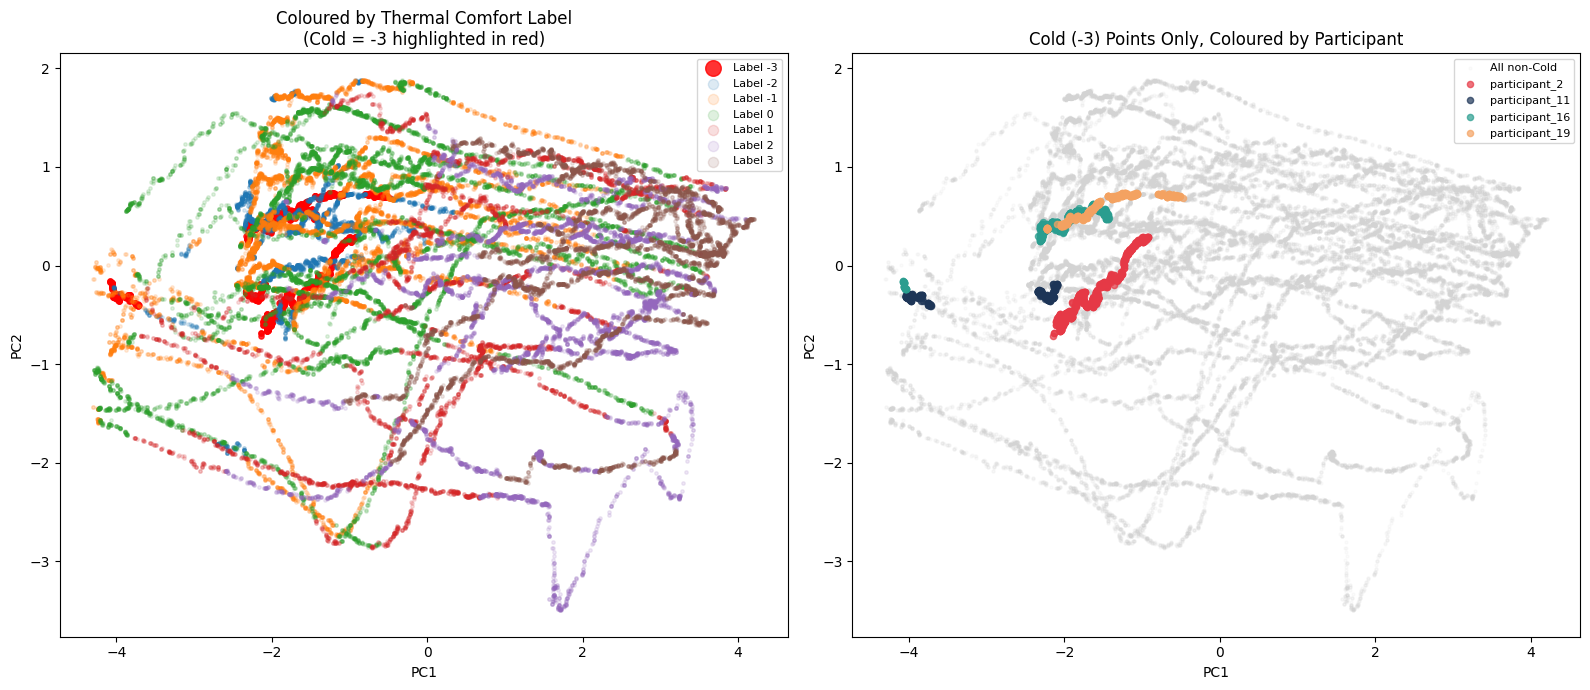

✅ Saved pca_cold_clustering.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# View 1 — coloured by thermal comfort label
ax = axes[0]
for label in sorted(sample_for_pca['Label'].unique()):
    subset = sample_for_pca[sample_for_pca['Label'] == label]
    alpha = 0.8 if label == -3 else 0.15
    size = 14 if label == -3 else 6
    color = 'red' if label == -3 else None
    ax.scatter(subset['PC1'], subset['PC2'], label=f'Label {label}',
               alpha=alpha, s=size, color=color)
ax.set_title('Coloured by Thermal Comfort Label\n(Cold = -3 highlighted in red)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=3, fontsize=8)

# View 2 — coloured by participant, Cold-reporters only, only their Cold rows
ax = axes[1]
non_cold_subset = sample_for_pca[sample_for_pca['Label'] != -3]
ax.scatter(non_cold_subset['PC1'], non_cold_subset['PC2'],
           alpha=0.08, s=5, color='lightgray', label='All non-Cold')

cold_reporters = ['participant_2', 'participant_11', 'participant_16', 'participant_19']
colors = ['#E63946', '#1D3557', '#2A9D8F', '#F4A261']
for pid, color in zip(cold_reporters, colors):
    p_cold = sample_for_pca[(sample_for_pca['participant_id'] == pid) &
                              (sample_for_pca['Label'] == -3)]
    ax.scatter(p_cold['PC1'], p_cold['PC2'], label=pid,
               alpha=0.7, s=20, color=color)

ax.set_title('Cold (-3) Points Only, Coloured by Participant')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('pca_cold_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved pca_cold_clustering.png")

In [37]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# Use the alternative split classifier and data you already trained
y_proba_alt = clf_alt.predict_proba(X_test_alt)
class_labels = clf_alt.classes_
print(f"Class order in predict_proba output: {class_labels}")

# Confusion matrix, focusing on Cold's row
cm = confusion_matrix(y_test_alt, y_pred_alt, labels=sorted(class_labels))
cm_df = pd.DataFrame(cm, index=sorted(class_labels), columns=sorted(class_labels))
print("\nFull confusion matrix (rows = true label, columns = predicted label):")
print(cm_df)

print("\n\nWhere do TRUE Cold (-3) samples actually get predicted?")
cold_row = cm_df.loc[-3]
cold_row_pct = (cold_row / cold_row.sum() * 100).round(2)
print(cold_row_pct)

Class order in predict_proba output: [-3 -2 -1  0  1  2  3]

Full confusion matrix (rows = true label, columns = predicted label):
    -3     -2     -1      0      1      2      3
-3   0  23498  15441      0      0      0      0
-2   0   2912  27914   6303      0      0      0
-1   0   4466  23000  27382   3687      0     90
 0   0    168   6856  11530  18388  11368   3569
 1   0      0    556   5913  16998   6874   4912
 2   0    369   1786   9566  10153  20610  10513
 3   0      0      0   2344      0   1313  15790


Where do TRUE Cold (-3) samples actually get predicted?
-3     0.00
-2    60.35
-1    39.65
 0     0.00
 1     0.00
 2     0.00
 3     0.00
Name: -3, dtype: float64


In [38]:
# Now the actual predicted PROBABILITIES for true Cold samples
cold_mask = (y_test_alt == -3)
cold_indices = np.where(cold_mask)[0]
print(f"Number of true Cold test samples: {len(cold_indices):,}")

cold_col_idx = list(class_labels).index(-3)

avg_proba_for_cold_samples = y_proba_alt[cold_indices].mean(axis=0)
proba_summary = pd.Series(avg_proba_for_cold_samples, index=class_labels).sort_values(ascending=False)

print("\nAverage predicted probability, across ALL true Cold samples, for each class:")
print(proba_summary.round(4))

print(f"\nMean probability assigned to the CORRECT class (Cold) when truth is Cold: {avg_proba_for_cold_samples[cold_col_idx]:.4f}")

# How many Cold samples got ANY meaningful probability mass on Cold at all?
cold_proba_values = y_proba_alt[cold_indices, cold_col_idx]
print(f"\nDistribution of P(Cold) assigned to true Cold samples:")
print(pd.Series(cold_proba_values).describe())
print(f"\n% of true Cold samples with P(Cold) > 0.3: {(cold_proba_values > 0.3).mean()*100:.2f}%")
print(f"% of true Cold samples with P(Cold) > 0.1: {(cold_proba_values > 0.1).mean()*100:.2f}%")
print(f"% of true Cold samples with P(Cold) < 0.01: {(cold_proba_values < 0.01).mean()*100:.2f}%")

Number of true Cold test samples: 38,939

Average predicted probability, across ALL true Cold samples, for each class:
-2    0.4308
-1    0.3194
-3    0.0924
 0    0.0798
 1    0.0428
 2    0.0341
 3    0.0007
dtype: float64

Mean probability assigned to the CORRECT class (Cold) when truth is Cold: 0.0924

Distribution of P(Cold) assigned to true Cold samples:
count    38939.000000
mean         0.092394
std          0.055208
min          0.010000
25%          0.040000
50%          0.090000
75%          0.150000
max          0.210000
dtype: float64

% of true Cold samples with P(Cold) > 0.3: 0.00%
% of true Cold samples with P(Cold) > 0.1: 44.53%
% of true Cold samples with P(Cold) < 0.01: 0.00%
